In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from explainerdashboard import RegressionExplainer, ExplainerDashboard

In [16]:
df = pd.read_csv('abalone_clear.csv',index_col=0)
df.reset_index(drop=True,inplace=True)
df

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
4,I,0.425,0.300,0.095,0.3515,0.1410,0.0775,0.1200,8
...,...,...,...,...,...,...,...,...,...
3928,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
3929,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
3930,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
3931,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


# 1. Построение моделей на числовых признаках с параметрами по умолчанию

### Подготовлю данные:

**Сначала разделение на X и y**

In [17]:
X = df.drop(['Sex','Rings'],axis=1)
y = df['Rings']

**Разделю на train & test**

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=245)

**Масштабирую**

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

### Обучение простых моделей:

#### Начну с Байеса

In [21]:
from sklearn.linear_model import BayesianRidge
baye = BayesianRidge()

In [183]:
baye.fit(scaled_X_train,y_train)

,"max_iter max_iter: int, default=300Maximum number of iterations over the complete dataset beforestopping independently of any early stopping criterion... versionchanged:: 1.3",300
,"tol tol: float, default=1e-3Stop the algorithm if w has converged.",0.001
,"alpha_1 alpha_1: float, default=1e-6Hyper-parameter : shape parameter for the Gamma distribution priorover the alpha parameter.",1e-06
,"alpha_2 alpha_2: float, default=1e-6Hyper-parameter : inverse scale parameter (rate parameter) for theGamma distribution prior over the alpha parameter.",1e-06
,"lambda_1 lambda_1: float, default=1e-6Hyper-parameter : shape parameter for the Gamma distribution priorover the lambda parameter.",1e-06
,"lambda_2 lambda_2: float, default=1e-6Hyper-parameter : inverse scale parameter (rate parameter) for theGamma distribution prior over the lambda parameter.",1e-06
,"alpha_init alpha_init: float, default=NoneInitial value for alpha (precision of the noise).If not set, alpha_init is 1/Var(y)... versionadded:: 0.22",None
,"lambda_init lambda_init: float, default=NoneInitial value for lambda (precision of the weights).If not set, lambda_init is 1... versionadded:: 0.22",None
,"compute_score compute_score: bool, default=FalseIf True, compute the log marginal likelihood at each iteration of theoptimization.",False
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model.The intercept is not treated as a probabilistic parameterand thus has no associated variance. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True


In [184]:
# Число колец должно получиться целым
baye_preds = np.round(baye.predict(scaled_X_test)).astype(int)

**Посмотрим метрики**

In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [185]:
# MAE
mean_absolute_error(baye_preds,y_test)

1.608739837398374

In [186]:
# RMSE
mean_squared_error(baye_preds,y_test) ** 0.5

2.277273723063632

In [187]:
print(f'Предсказание модели в среднем отличается на {np.round(mean_absolute_error(baye_preds,y_test) /df.Rings.mean() * 100).astype(int)}% от типичного количества колец')

Предсказание модели в среднем отличается на 16% от типичного количества колец


In [188]:
# Без округления preds, r2 будет немного больше
print(f'Модель объясняет {np.round(r2_score(y_test,baye_preds),3) * 100}% вариации колец')

Модель объясняет 51.300000000000004% вариации колец


#### Теперь использую KNN

In [54]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor()

In [189]:
knn.fit(scaled_X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


In [190]:
knn_preds = np.round(knn.predict(scaled_X_test)).astype(int)

**Посмотрим метрики**

In [191]:
# MAE
mean_absolute_error(knn_preds,y_test)

1.6666666666666667

In [192]:
# RMSE
mean_squared_error(knn_preds,y_test) ** 0.5

2.4042645039342174

In [193]:
print(f'Предсказание модели в среднем отличается на {np.round(mean_absolute_error(knn_preds,y_test) /df.Rings.mean() * 100).astype(int)}% от типичного количества колец')

Предсказание модели в среднем отличается на 17% от типичного количества колец


In [194]:
print(f'Модель объясняет {np.round(r2_score(y_test,knn_preds),3) * 100}% вариации колец')

Модель объясняет 45.800000000000004% вариации колец


Результат получился несколько хуже 

#### Попробую более сложный алгоритм

In [103]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()

In [195]:
rf.fit(scaled_X_train,y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",245
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"

In [196]:
rf_preds = np.round(rf.predict(scaled_X_test)).astype(int)

**Посмотрим метрики**

In [197]:
# MAE
mean_absolute_error(rf_preds,y_test)

1.5802845528455285

In [198]:
# RMSE
mean_squared_error(rf_preds,y_test) ** 0.5

2.2598024951471247

In [199]:
print(f'Предсказание модели в среднем отличается на {np.round(mean_absolute_error(rf_preds,y_test) /df.Rings.mean() * 100).astype(int)}% от типичного количества колец')

Предсказание модели в среднем отличается на 16% от типичного количества колец


In [200]:
print(f'Модель объясняет {np.round(r2_score(y_test,rf_preds),3) * 100}% вариации колец')

Модель объясняет 52.1% вариации колец


Ненастроенная модель даёт +- те же результаты

---

# 2. Подбор гиперпараметров для этих моделей

In [110]:
from sklearn.model_selection import GridSearchCV

#### Для KNN:

In [210]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 20, 25, 30],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]
}

knn = KNeighborsRegressor()

grid = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=10
)

In [211]:
grid.fit(scaled_X_train,y_train)

Fitting 3 folds for each of 120 candidates, totalling 360 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan', ...], 'n_neighbors': [3, 5, ...], 'p': [1, 2], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_au

**Лучшие параметры:**

In [212]:
grid.best_params_

{'metric': 'manhattan', 'n_neighbors': 9, 'p': 1, 'weights': 'distance'}

In [213]:
grid_preds = np.round(grid.predict(scaled_X_test)).astype(int)

**Посмотрим метрики**

In [214]:
# MAE
mean_absolute_error(grid_preds,y_test)

1.5995934959349594

In [215]:
# RMSE
mean_squared_error(grid_preds,y_test) ** 0.5

2.343907515032193

In [216]:
print(f'Предсказание модели в среднем отличается на {np.round(mean_absolute_error(grid_preds,y_test) /df.Rings.mean() * 100).astype(int)}% от типичного количества колец')

Предсказание модели в среднем отличается на 16% от типичного количества колец


In [217]:
print(f'Модель объясняет {np.round(r2_score(y_test,grid_preds),3) * 100}% вариации колец')

Модель объясняет 48.5% вариации колец


**Результат стал чуть лучше**

#### Для RF:

In [218]:
param_grid = {
    'n_estimators': [50, 100, 150, 200, 300],
    'max_depth': [5, 7, 10, 12, 15, None],
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7]
}

rf = RandomForestRegressor(random_state=245, n_jobs=-1)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=10
)

In [219]:
grid.fit(scaled_X_train,y_train)

Fitting 3 folds for each of 150 candidates, totalling 450 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...dom_state=245)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 7, ...], 'max_features': ['sqrt', 'log2', ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_mo

In [220]:
grid.best_params_

{'max_depth': 10, 'max_features': 0.5, 'n_estimators': 300}

In [221]:
grid_preds = np.round(grid.predict(scaled_X_test)).astype(int)

**Посмотрим метрики**

In [222]:
# MAE
mean_absolute_error(grid_preds,y_test)

1.5538617886178863

In [223]:
# RMSE
mean_squared_error(grid_preds,y_test) ** 0.5

2.243101438865539

In [224]:
print(f'Предсказание модели в среднем отличается на {np.round(mean_absolute_error(grid_preds,y_test) /df.Rings.mean() * 100).astype(int)}% от типичного количества колец')

Предсказание модели в среднем отличается на 16% от типичного количества колец


In [227]:
print(f'Модель объясняет {np.round(r2_score(y_test,grid_preds),3) * 100}% вариации колец')

Модель объясняет 52.800000000000004% вариации колец


**Тоже капельку лучше ненастроенной версии**

---

# 3. Обучение лучшей модели с добавлением категориальных признаков

**Лучше себя показал RF, с ним и буду работать**

In [250]:
X = pd.get_dummies(df.drop('Rings',axis=1),dtype=float,drop_first=True)
y = df['Rings']

**Разделю на train & test**

In [251]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=245)

### Снова подберу гиперпараметры:

In [252]:
param_grid = {
    'n_estimators': [50, 100, 150, 200, 300],
    'max_depth': [5, 7, 10, 12, 15, None],
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7]
}

rf = RandomForestRegressor(random_state=245, n_jobs=-1)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=10
)

In [253]:
grid.fit(X_train,y_train)

Fitting 3 folds for each of 150 candidates, totalling 450 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...dom_state=245)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 7, ...], 'max_features': ['sqrt', 'log2', ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_mo

**Лучшие параметры:**

In [254]:
grid.best_params_

{'max_depth': 10, 'max_features': 0.5, 'n_estimators': 300}

In [255]:
grid_preds = np.round(grid.predict(X_test)).astype(int)

**Посмотрим метрики**

In [256]:
# MAE
mean_absolute_error(grid_preds,y_test)

1.5518292682926829

In [257]:
# RMSE
mean_squared_error(grid_preds,y_test) ** 0.5

2.2399277717739534

In [258]:
print(f'Предсказание модели в среднем отличается на {np.round(mean_absolute_error(grid_preds,y_test) /df.Rings.mean() * 100).astype(int)}% от типичного количества колец')

Предсказание модели в среднем отличается на 16% от типичного количества колец


In [259]:
print(f'Модель объясняет {np.round(r2_score(y_test,grid_preds),3) * 100}% вариации колец')

Модель объясняет 52.900000000000006% вариации колец


**Результат не поменялся :(**

---

# 4. Построение Explainer Dashboard

In [264]:
explainer = RegressionExplainer(grid,X_test,y_test)

C:\Users\whati\.conda\envs\ds\Lib\site-packages\explainerdashboard\explainers.py:403: UserWarning:


C:\Users\whati\.conda\envs\ds\Lib\site-packages\explainerdashboard\explainers.py:425: UserWarning:

For shap='kernel', shap interaction values cannot be calculated.

C:\Users\whati\.conda\envs\ds\Lib\site-packages\explainerdashboard\explainers.py:1471: UserWarning:

Shap values for shap.KernelExplainer are calculated against X_background, but X_background=None, so using shap.sample(X, 50) instead.



In [265]:
db = ExplainerDashboard(explainer)

C:\Users\whati\.conda\envs\ds\Lib\site-packages\explainerdashboard\dashboards.py:723: UserWarning:

Detected notebook environment, consider setting mode='external', mode='inline' or mode='jupyterlab' to keep the notebook interactive while the dashboard is running...

C:\Users\whati\.conda\envs\ds\Lib\site-packages\explainerdashboard\dashboards.py:815: UserWarning:

For this type of model and model_output interactions don't work, so setting shap_interaction=False...

C:\Users\whati\.conda\envs\ds\Lib\site-packages\explainerdashboard\dashboards.py:822: UserWarning:

The explainer object has no decision_trees property, so setting decision_trees=False...



  0%|          | 0/984 [00:00<?, ?it/s]

In [268]:
db.run(host='127.0.0.1', port=8050)

C:\Users\whati\.conda\envs\ds\Lib\site-packages\explainerdashboard\explainers.py:862: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

C:\Users\whati\.conda\envs\ds\Lib\site-packages\explainerdashboard\explainers.py:862: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

C:\Users\whati\.conda\envs\ds\Lib\site-packages\explainerdashboard\explainers.py:862: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set

In [269]:
db.save_html('abalone_dashboard.html') 

---

# 5. Анализ модели в Explainer Dashboard

### Какие факторы наиболее важны в среднем для получения прогноза? 

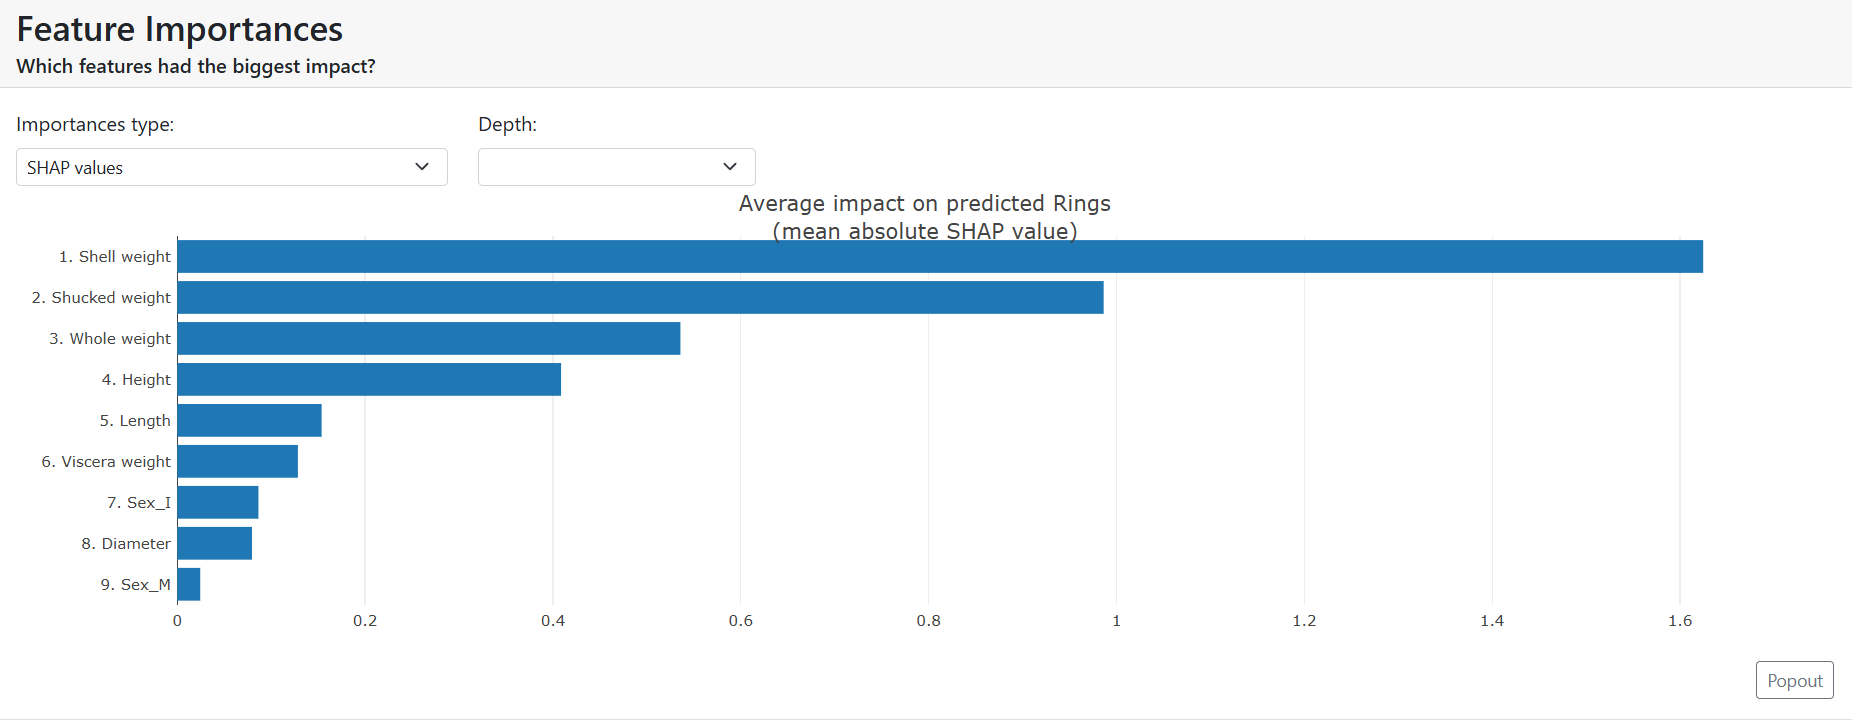

Наиболее важными являются shell weight и shucked weight

### Какие значения метрик получились и что это значит?

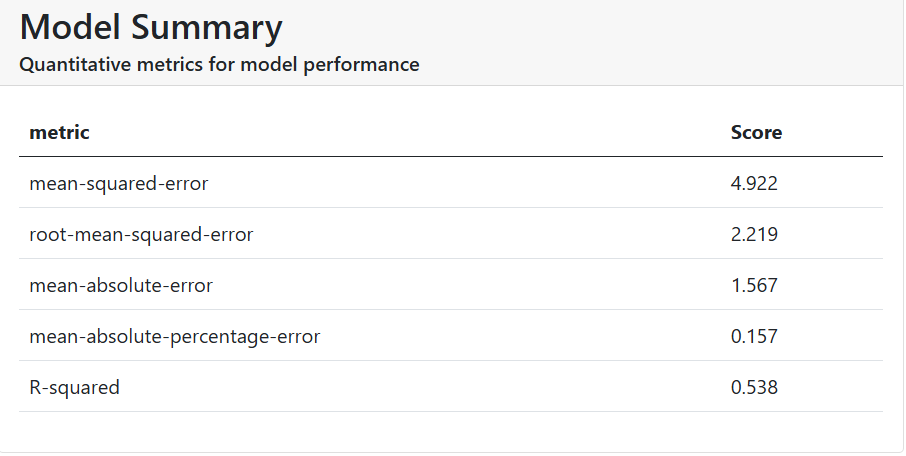

Средняя абсолюная ошибка - полтора кольца  
Среднеквадратичная ошибка (RMSE) заметно больше MAE. Это говорит о том, что есть предсказания с большими остатками  
В среднем модель ошибается на 15.7%  
Модель объясняет ~54% дисперсии количества колец

### Анализ индивидуальных прогнозов

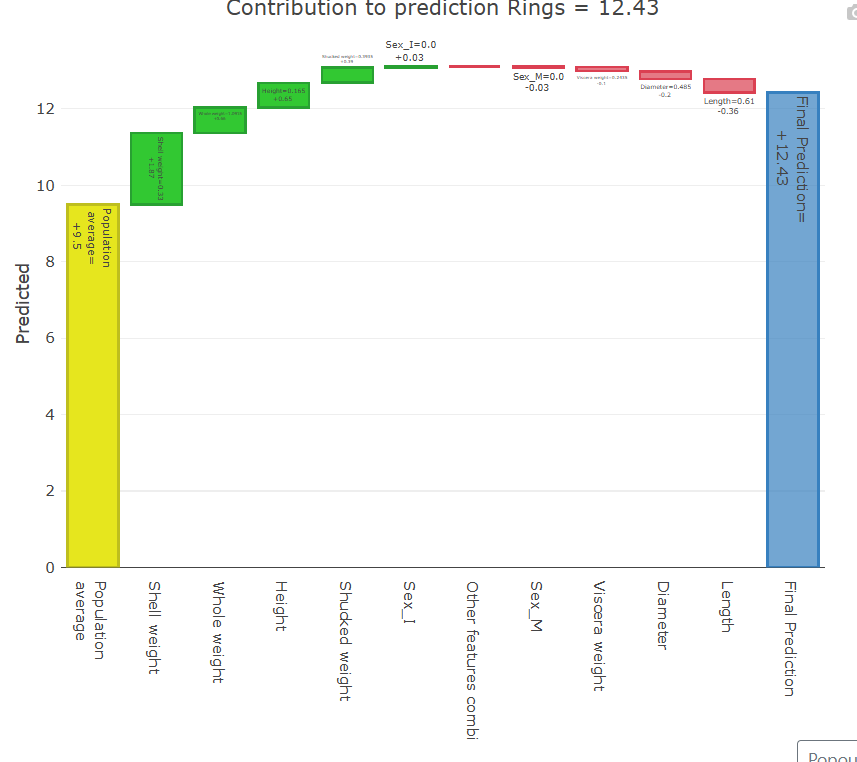

Как и в общем случае, наибольшее влияние оказывают признаки, связанные с весом  
Здесь имеется большой вес, но модель смутила недостаточная длина, которая занизила прогноз

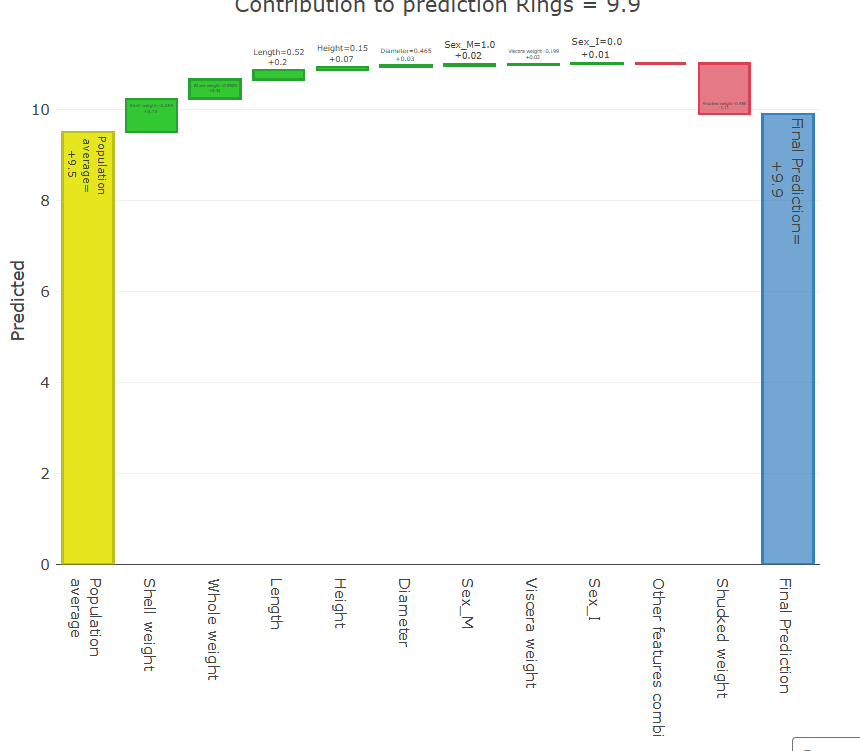

В этом случае были большие shell weight и whole weight, но shucked weight заметно снизил прогнозируемое количество колец 

---